In [12]:
import pandas as pd 
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import datetime as dt 
import importlib
import helpers
importlib.reload(helpers)

from helpers import data_extraction,montecarlosims, ConfigLoader


# get the data of my portfolio 




In [3]:
# read config file
config=ConfigLoader.configload()
config


{'stocks': ['PLTR',
  'AAPL',
  'MSFT',
  'NVDA',
  'BMNR',
  'BABA',
  'SOFI',
  'AVPT',
  'CRM',
  'GOOG',
  'DKNG',
  'LMT',
  'NOC',
  'NFLX',
  'PG',
  'UNH',
  'ADBE'],
 'weigths': [0.43,
  0.06,
  0.07,
  0.06,
  0.02,
  0.04,
  0.03,
  0.03,
  0.04,
  0.05,
  0.02,
  0.005,
  0.005,
  0.04,
  0.05,
  0.05,
  0.01]}

In [27]:
# get the data of my portfolio 
end=dt.datetime(year=2025,month=12,day=31)
start=dt.datetime(year=2020,month=1,day=1)
meanReturns,Covmatrix=data_extraction.get_data(config['stocks'],start,end)


[*********************100%***********************]  17 of 17 completed


Monte Carlo Simulation:

1) Simulate random shocks 
2) Add the random shocks with Covariance matrix of the stocks 
3) Generate daily returns and cumulative returns over timeframe 

VAR:
- loss threshold for portfolio managers to note that there is a 5 % chance losses exceed VaR. If Losses does exceed VAR it also shows the Monte Carlo Simulation model has a problem 


CVAR (Conditional VaR):
- Average losses given that you are at the worst 5% of outcomes. This is useful for really grim outlooks/pessimism.




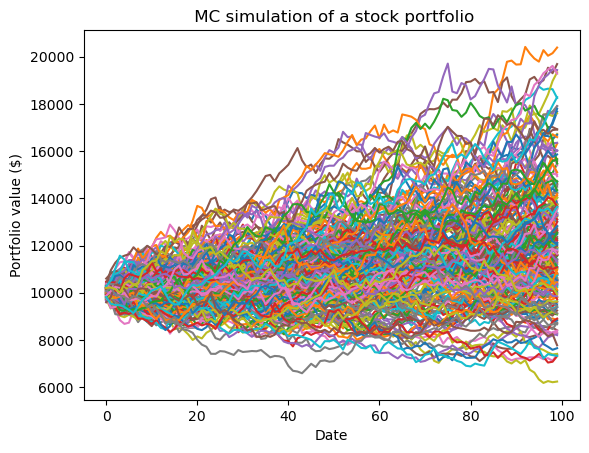

Expected return: 12331.835709165824
Median return: 11954.372952024587
Loss probability: 0.185
VaR (95%): 1607.86
CVaR (95%): 2410.01


In [28]:
# run monte carlo sims , var on my losses 
montecarlosims.monte_carlo(100,Covmatrix,200,meanReturns,config['weigths'],10000)


We wish to find out why the loss probability is so high at 28.5%?

We will try to delve in deeper into understanding how we can reduce our downside

1) Whether the loss probability is driven by systematic risk (interest rate etc)
2) How much unsystematic risk is my portfolio exposed?

Hypothesis: Alot of Tech stocks hence, very little diversification and hence, high unsystematic risk



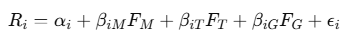

Running of Factor models:

We have decided to run factor models using factors:

- US 500 (market) -> This is market risk encapsulating economy wide shocks, interest rate changes and macro changes
- Tech factor (XLK) -> This is with regards to me being heavy on tech stocks. Hence, we are trying to segregate sector risk from market risk
- HML -> Value vs growth spread. This captures discount rate sensitivity and duration risk 
- SMB -> Size of company. Small cap premium or high business risk


Credits to https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/Data_Library/f-f_factors.html

for the Fama French daily data


In [37]:
# read csv file in additional data 
ff_data = pd.read_csv("additional data/F-F_Research_Data_Factors_daily.CSV", skiprows=4)
ff_data.rename(columns={'Unnamed: 0':'Date'},inplace=True)
ff_data=ff_data.dropna(axis=0)
ff_data["Date"] = pd.to_datetime(ff_data["Date"], format="%Y%m%d")
ff_data=ff_data[ff_data['Date']>=start]
ff_data.set_index(ff_data['Date'],inplace=True)
ff_data.drop(columns='Date',inplace=True)